In [ ]:
!pip install git+https://github.com/openai/CLIP.git
!pip install segment-anything opencv-python matplotlib

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-h8t9mtsn
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-h8t9mtsn
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import clip
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)

In [ ]:
image = Image.open("/content/glioma.jpg")

input_image = preprocess(image).unsqueeze(0).to(device)

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

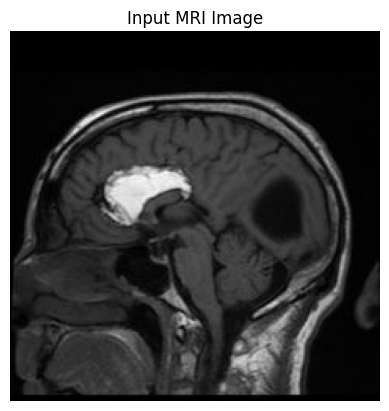

In [ ]:
plt.imshow(image)
plt.title("Input MRI Image")
plt.axis("off")

In [ ]:
text_prompts = [
"normal brain MRI",
"brain tumor"
]

text_tokens = clip.tokenize(text_prompts).to(device)

In [ ]:
with torch.no_grad():
    image_features = clip_model.encode_image(input_image)
    text_features = clip_model.encode_text(text_tokens)

print("Image feature shape:", image_features.shape)
print("Text feature shape:", text_features.shape)

Image feature shape: torch.Size([1, 512])
Text feature shape: torch.Size([2, 512])


In [ ]:
similarity = (image_features @ text_features.T).softmax(dim=-1)

print("Similarity scores:",similarity)

Similarity scores: tensor([[0.0298, 0.9702]], device='cuda:0', dtype=torch.float16)


(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

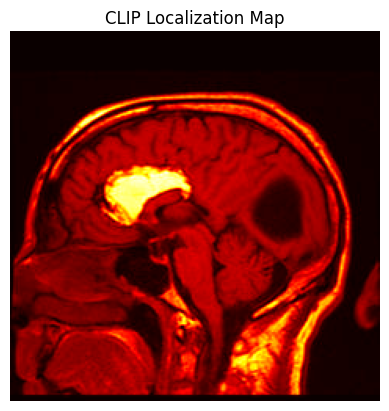

In [ ]:
img_cv = cv2.imread("/content/glioma.jpg")
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img_cv, cv2.COLOR_RGB2GRAY)

saliency_map = gray / gray.max()

plt.imshow(saliency_map, cmap="hot")
plt.title("CLIP Localization Map")
plt.axis("off")

In [ ]:
y, x = np.unravel_index(np.argmax(saliency_map), saliency_map.shape)

point_coords = np.array([[x, y]])
point_labels = np.array([1])

In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-07 20:45:02--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.51, 3.163.189.108, 3.163.189.96, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.51|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth.1’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   252MB/s    in 1.4s    

2026-03-07 20:45:03 (252 MB/s) - ‘sam_vit_b_01ec64.pth.1’ saved [375042383/375042383]



In [ ]:
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "sam_vit_b_01ec64.pth"

sam_model = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)

sam_model.to(device)

predictor = SamPredictor(sam_model)

In [ ]:
predictor.set_image(img_cv)

masks, scores, logits = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)
print("Number of masks:", len(masks))



Number of masks: 3


In [ ]:
best_mask = masks[np.argmax(scores)]

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

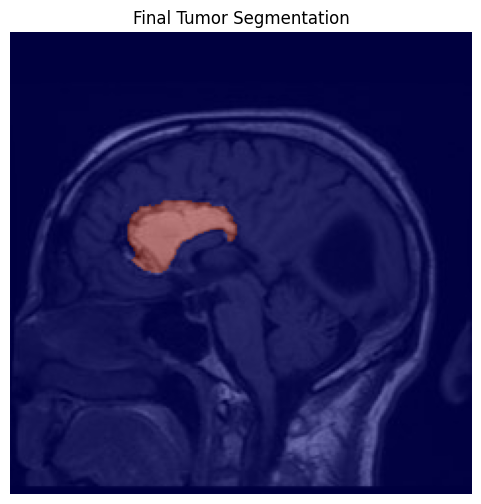

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(img_cv)
plt.imshow(best_mask, alpha=0.5, cmap="jet")

plt.title("Final Tumor Segmentation")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

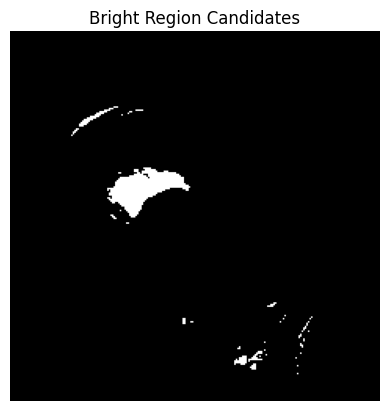

In [ ]:
gray = cv2.cvtColor(img_cv, cv2.COLOR_RGB2GRAY)

# normalize
gray = gray / gray.max()

# threshold bright tumor region
_, thresh = cv2.threshold((gray*255).astype(np.uint8), 180, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap="gray")
plt.title("Bright Region Candidates")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

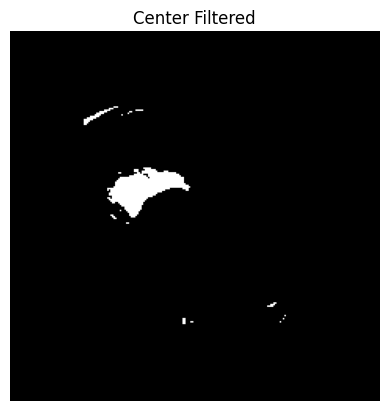

In [ ]:
h, w = thresh.shape

mask_center = np.zeros_like(thresh)

x1 = int(w*0.2)
x2 = int(w*0.8)
y1 = int(h*0.2)
y2 = int(h*0.8)

mask_center[y1:y2, x1:x2] = 255

thresh_center = cv2.bitwise_and(thresh, mask_center)

plt.imshow(thresh_center, cmap="gray")
plt.title("Center Filtered")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

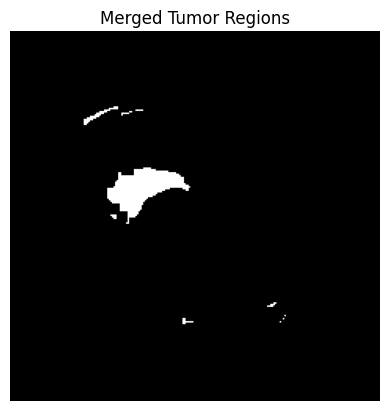

In [ ]:
kernel = np.ones((7,7), np.uint8)

merged = cv2.morphologyEx(thresh_center, cv2.MORPH_CLOSE, kernel)

plt.imshow(merged, cmap="gray")
plt.title("Merged Tumor Regions")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

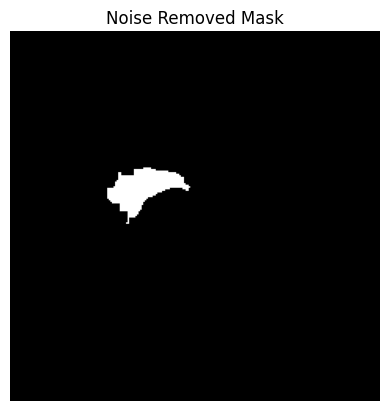

In [ ]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(merged)

# minimum tumor area threshold
min_area = 200

clean_mask = np.zeros_like(merged)

for i in range(1, num_labels):  # 0 background hota hai
    if stats[i, cv2.CC_STAT_AREA] > min_area:
        clean_mask[labels == i] = 255

plt.imshow(clean_mask, cmap="gray")
plt.title("Noise Removed Mask")
plt.axis("off")

In [ ]:
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

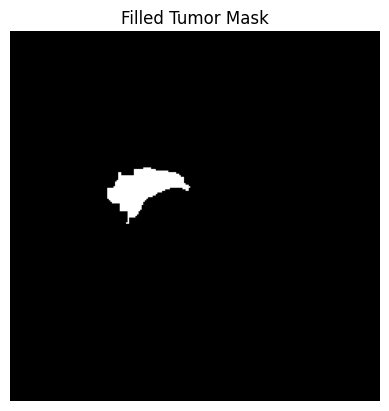

In [ ]:
tumor_mask = np.zeros_like(clean_mask)

for cnt in contours:
    if cv2.contourArea(cnt) > 50:   # small noise ignore
        cv2.drawContours(tumor_mask, [cnt], -1, 255, thickness=cv2.FILLED)

plt.imshow(tumor_mask, cmap="gray")
plt.title("Filled Tumor Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

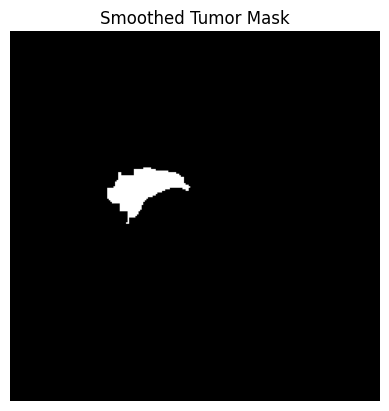

In [ ]:
kernel = np.ones((7,7), np.uint8)
tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_CLOSE, kernel)

plt.imshow(tumor_mask, cmap="gray")
plt.title("Smoothed Tumor Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

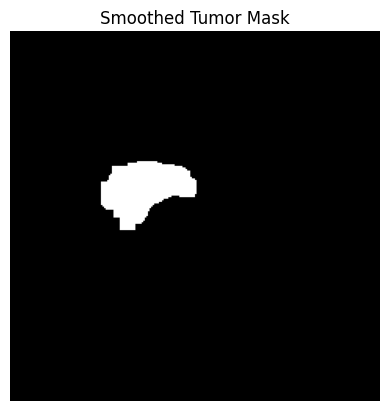

In [ ]:
kernel = np.ones((9,9), np.uint8)

smooth_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_CLOSE, kernel)

smooth_mask = cv2.dilate(smooth_mask, kernel, iterations=1)

plt.imshow(smooth_mask, cmap="gray")
plt.title("Smoothed Tumor Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

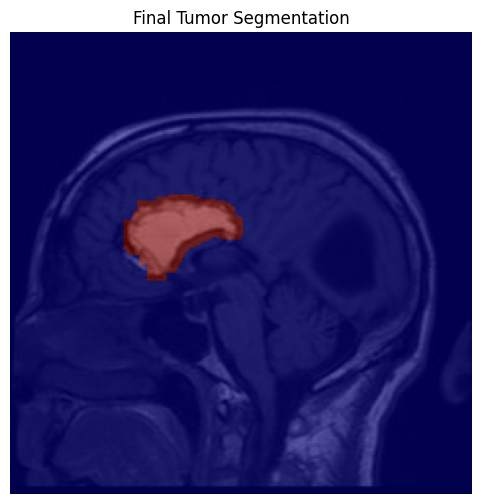

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(img_cv)
plt.imshow(smooth_mask, alpha=0.6, cmap="jet")

plt.title("Final Tumor Segmentation")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

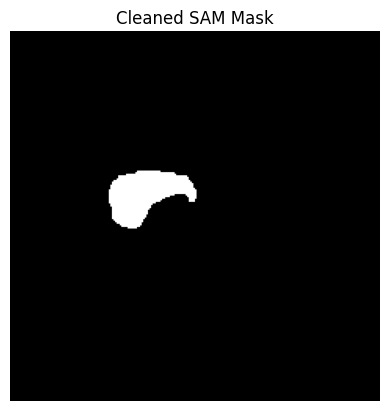

In [ ]:
# Convert boolean mask to uint8
mask = best_mask.astype(np.uint8) * 255

# Morphological smoothing
kernel = np.ones((4,4), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

plt.imshow(mask, cmap="gray")
plt.title("Cleaned SAM Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

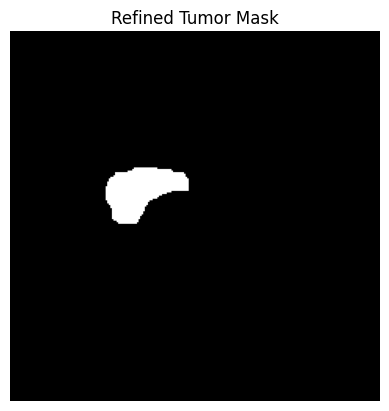

In [ ]:
mask_uint8 = best_mask.astype(np.uint8) * 255

kernel = np.ones((8,8), np.uint8)
clean_mask = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel)

plt.imshow(clean_mask, cmap="gray")
plt.title("Refined Tumor Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(235.5), np.float64(235.5), np.float64(-0.5))

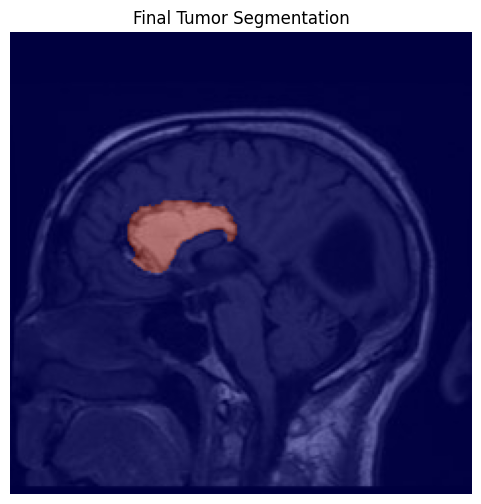

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(img_cv)
plt.imshow(best_mask, alpha=0.5, cmap="jet")

plt.title("Final Tumor Segmentation")
plt.axis("off")